# 23. 처치 사건 찾기: 한 시장에만 걸린 일이 있었나

## Overview

22번에서 **시장 축은 살아 있지만 평행추세가 약하다**는 결과가 나왔습니다.
시장 간 가격차는 실재하고 방향도 일관되는데(가락이 전 품목에서 비쌈),
그 격차가 시간에 따라 계속 흔들립니다.

**그래도 DiD 가 성립할 여지는 남아 있습니다.** 처치 효과가 그 흔들림보다
크면 됩니다. 문제는 **아직 처치가 뭔지 모른다**는 것입니다.

이 문서는 그걸 데이터에서 찾습니다. **사건이 없으면 여기서 인과 설계를
접습니다.**

## 방법

**상대가격**을 만듭니다: 그날 그 품목의 **시장 평균 대비 편차**입니다.

```
상대가격(품목 i, 시장 m, 날짜 t) = log(가격) - 그날 그 품목의 시장 평균 log(가격)
```

이렇게 하면 전국 공통 충격(작황·계절·명절)이 빠지고 **시장 고유의 움직임만**
남습니다. 22번에서 본 "가락이 비싸다" 같은 상시 격차도 각 시장의 평소 수준으로
잡아 빼면, 남는 건 **평소와 다른 구간**입니다.

## 사건을 두 종류로 가릅니다

| 몇 품목에 걸렸나 | 무엇으로 읽나 | DiD 쓸모 |
|---|---|---|
| **여러 품목 동시** | 그 시장 전체에 걸린 일(휴장·물류·제도) | **높음** |
| 품목 하나만 | 그 품목의 작황·수급 | 낮음 |

여러 품목이 같이 움직여야 "시장에 무슨 일이 있었다"고 말할 수 있습니다.
품목 하나만 튀면 그건 시장 사건이 아니라 그 품목 사건입니다.

## 판정 기준을 먼저 정합니다

결과를 보고 정하면 룩어헤드입니다(교훈 5).

| 기준 | 값 | 왜 |
|---|---|---|
| 이탈 크기 | 로버스트 z **3 이상** | 평소 흔들림의 3배 |
| 지속 | **5거래일 이상** | 하루 튀는 건 노이즈 |
| 시장 사건 조건 | **3품목 이상** 동시 | 그래야 시장 전체 |

## 목차

1. 상대가격 만들기
2. 시장 전체 지수와 평소 수준
3. 이탈 구간 찾기
4. 몇 품목에 걸렸나
5. 관측 공백 (휴장 후보)
6. 정리

## 1. 상대가격 만들기

22번에서 확인한 규칙을 지킵니다: 그레인은 `kindname_raw`, 미거래는 제외,
주력 5시장만, 깐마늘은 규격 구성이 달라 뺍니다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager

_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
obs = pd.read_parquet(ROOT / "notebooks" / ".cache" / "wholesale_obs.parquet")
obs["price_date"] = pd.to_datetime(obs["price_date"])

MAIN = ["가락도매", "오정도매", "서부도매", "북부도매", "엄궁도매"]
제외품목 = ["깐마늘(국산)"]          # 22번: 규격 구성이 시장마다 다름(TVD 49.9%)

Z컷, 최소지속, 최소품목 = 3.0, 5, 3      # 미리 정한 판정 기준

t = obs[obs.market.isin(MAIN)
        & ~obs.item.isin(제외품목)
        & (~obs.no_trade.fillna(False))
        & obs.price.notna() & (obs.price > 0)].copy()
t["_logp"] = np.log(t.price)

# 그레인이 kindname_raw 이므로 그 단위로 먼저 접은 뒤 품목으로 올린다
g = (t.groupby(["item", "kindname_raw", "market", "price_date"])._logp.mean()
      .groupby(level=["item", "market", "price_date"]).mean().rename("logp")
      .reset_index())

# 상대가격: 그날 그 품목의 시장 평균 대비 편차
g["시장수"] = g.groupby(["item", "price_date"]).market.transform("nunique")
g = g[g.시장수 >= 4]                       # 최소 4개 시장이 같이 있는 날만
g["상대가격"] = g.logp - g.groupby(["item", "price_date"]).logp.transform("mean")

print(f"{len(g):,}행 | 품목 {g.item.nunique()} · 시장 {g.market.nunique()}")
print(f"기간 {g.price_date.min():%Y-%m-%d} ~ {g.price_date.max():%Y-%m-%d}")
print(f"\n판정 기준: z >= {Z컷} 가 {최소지속}거래일 이상 지속 · {최소품목}품목 이상 동시")
display(g.groupby("market").상대가격.agg(["mean", "std", "size"]).round(3))

109,216행 | 품목 17 · 시장 5
기간 2021-01-04 ~ 2026-08-07

판정 기준: z >= 3.0 가 5거래일 이상 지속 · 3품목 이상 동시


,mean,std,size
market,,,
가락도매,0.061,0.131,21903
북부도매,-0.030,0.095,21892
서부도매,-0.018,0.106,21715
엄궁도매,-0.024,0.085,21895
오정도매,0.012,0.111,21811


## 2. 시장 전체 지수와 평소 수준

품목별 상대가격을 **시장 단위로 평균**내면 그 시장의 전체 지수가 됩니다.
`R(시장 m, 날짜 t) = 그날 그 시장의 품목 평균 상대가격`

이 지수가 **평소 수준**(60거래일 중앙값)에서 얼마나 벗어났는지를 봅니다.
표준편차 대신 **MAD**(중앙값 절대편차)를 쓰는 이유는, 사건 자체가 표준편차를
부풀려 자기 자신을 못 찾게 만들기 때문입니다.

In [2]:
R = (g.groupby(["market", "price_date"])
      .agg(지수=("상대가격", "mean"), 품목수=("item", "nunique"))
      .reset_index().sort_values(["market", "price_date"]))


def 로버스트z(s, win=60):
    med = s.rolling(win, min_periods=20, center=True).median()
    mad = (s - med).abs().rolling(win, min_periods=20, center=True).median()
    return (s - med) / (1.4826 * mad.replace(0, np.nan))


R["z"] = R.groupby("market").지수.transform(로버스트z)
R["이탈"] = R.z.abs() >= Z컷

print("시장별 이탈일 수")
display(R.groupby("market").agg(관측일=("z", "size"),
                                이탈일=("이탈", "sum"),
                                이탈비율=("이탈", lambda s: s.mean() * 100)).round(2))
print(f"z >= {Z컷} 는 평소 흔들림의 3배입니다. 정규분포라면 0.3% 쯤 나옵니다.")

시장별 이탈일 수


,관측일,이탈일,이탈비율
market,,,
가락도매,1372,25,1.82
북부도매,1372,17,1.24
서부도매,1372,13,0.95
엄궁도매,1372,31,2.26
오정도매,1372,22,1.60


z >= 3.0 는 평소 흔들림의 3배입니다. 정규분포라면 0.3% 쯤 나옵니다.


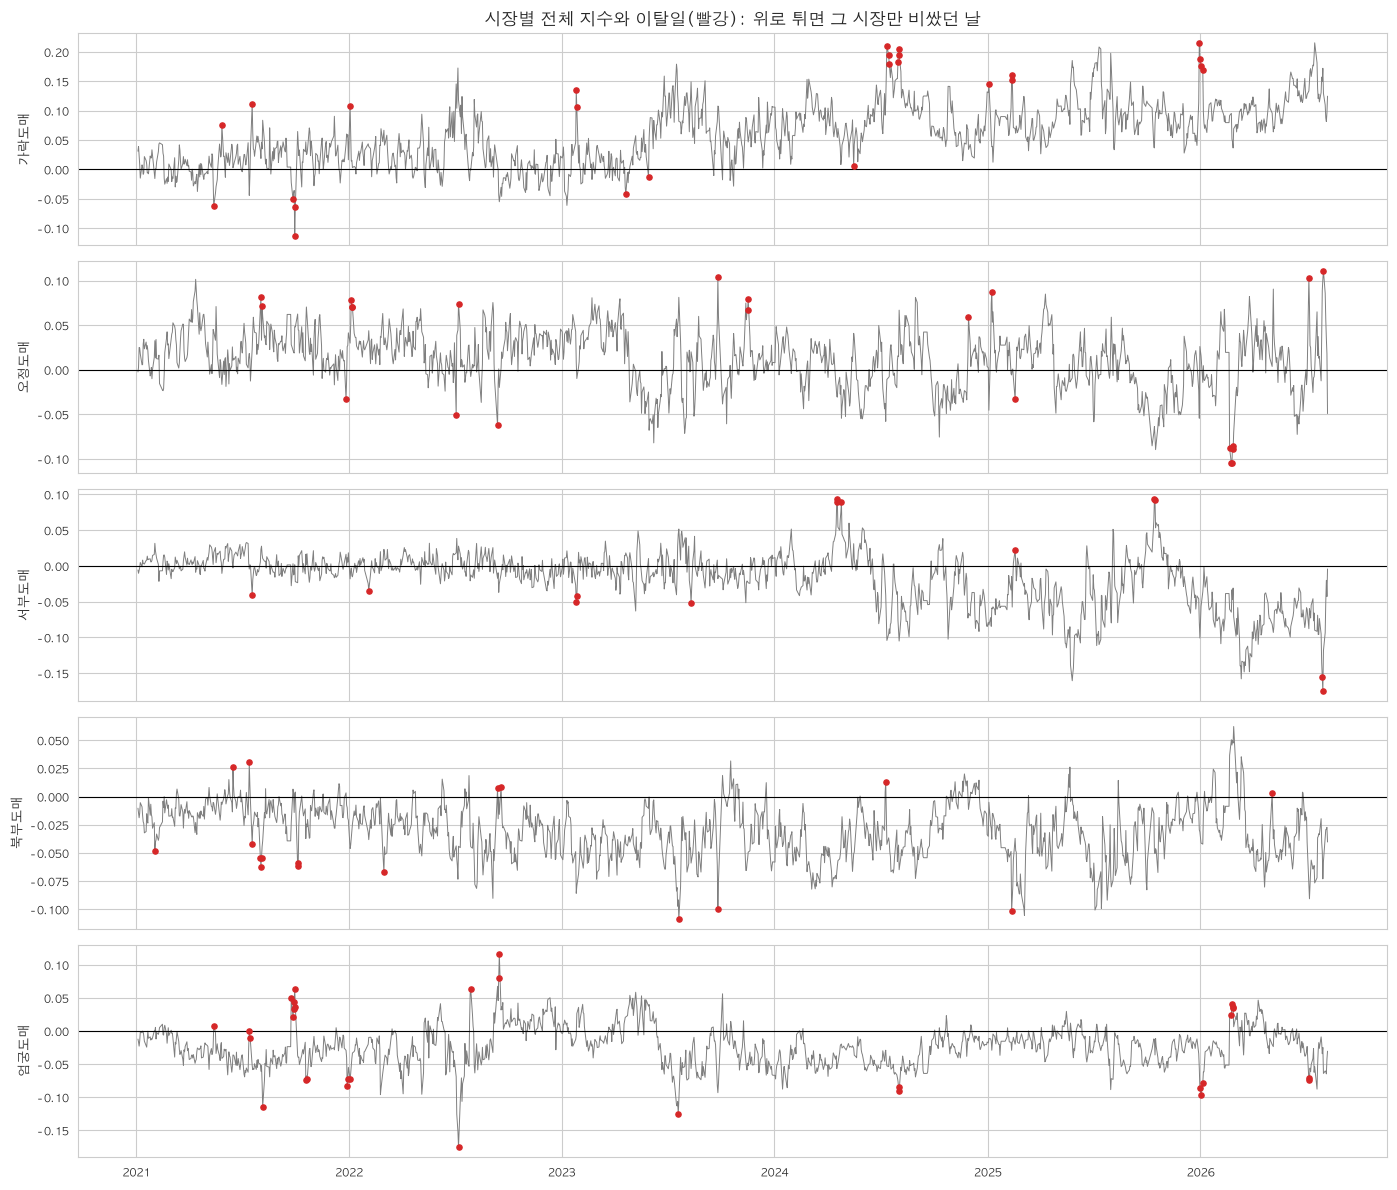

In [3]:
fig, axes = plt.subplots(len(MAIN), 1, figsize=(14, 12), sharex=True)
for ax, m in zip(axes, MAIN):
    s = R[R.market == m]
    ax.plot(s.price_date, s.지수, lw=0.7, color="tab:gray")
    hit = s[s.이탈]
    ax.scatter(hit.price_date, hit.지수, s=14, color="tab:red", zorder=3)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel(m, fontsize=9)
    ax.tick_params(labelsize=8)
axes[0].set_title("시장별 전체 지수와 이탈일(빨강): 위로 튀면 그 시장만 비쌌던 날",
                  fontsize=12)
plt.tight_layout()
plt.show()

## 3. 이탈 구간 찾기

하루짜리는 버리고 **5거래일 이상 이어진 구간**만 남깁니다. 사건이라면
며칠은 이어져야 합니다.

In [4]:
def 구간찾기(df, 최소=최소지속):
    out = []
    for m, s in df.groupby("market"):
        s = s.sort_values("price_date").reset_index(drop=True)
        run, sign = [], 0
        for i, row in s.iterrows():
            cur = np.sign(row.z) if row.이탈 else 0
            if cur != 0 and (sign == 0 or cur == sign):
                run.append(i)
                sign = cur
            else:
                if len(run) >= 최소:
                    seg = s.loc[run]
                    out.append({"market": m, "시작": seg.price_date.min(),
                                "끝": seg.price_date.max(), "일수": len(seg),
                                "방향": "비쌈" if sign > 0 else "쌈",
                                "평균 z": seg.z.mean(),
                                "평균 지수": seg.지수.mean()})
                run, sign = ([i], cur) if cur != 0 else ([], 0)
        if len(run) >= 최소:
            seg = s.loc[run]
            out.append({"market": m, "시작": seg.price_date.min(),
                        "끝": seg.price_date.max(), "일수": len(seg),
                        "방향": "비쌈" if sign > 0 else "쌈",
                        "평균 z": seg.z.mean(), "평균 지수": seg.지수.mean()})
    return pd.DataFrame(out)


구간 = 구간찾기(R)
print(f"{최소지속}거래일 이상 이어진 이탈 구간: {len(구간)}개")
if len(구간):
    display(구간.sort_values("일수", ascending=False).head(20).round(2))
else:
    print("없습니다.")

5거래일 이상 이어진 이탈 구간: 2개


/var/folders/my/g6ylslf57hbfhkcr32vt1xgr0000gn/T/ipykernel_31884/135434974.py:32: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(구간.sort_values("일수", ascending=False).head(20).round(2))


,market,시작,끝,일수,방향,평균 z,평균 지수
0,엄궁도매,2021-09-24,2021-10-01,6,비쌈,7.47,0.04
1,오정도매,2026-02-20,2026-02-26,5,쌈,-3.45,-0.09


## 4. 몇 품목에 걸렸나

**여기가 갈림길입니다.** 구간마다 그 시장의 품목들이 **같은 방향으로** 움직였는지
셉니다. 3품목 이상이면 시장 전체 사건, 1~2품목이면 그 품목 사건입니다.

In [5]:
rows = []
for _, e in 구간.iterrows():
    win = g[(g.market == e.market) & (g.price_date >= e.시작) & (g.price_date <= e.끝)]
    base = g[(g.market == e.market)
             & (g.price_date >= e.시작 - pd.Timedelta(days=90))
             & (g.price_date < e.시작)]
    b = base.groupby("item").상대가격.median()
    w = win.groupby("item").상대가격.median()
    diff = (w - b).dropna()
    같은방향 = (diff > 0) if e.방향 == "비쌈" else (diff < 0)
    큰변화 = diff.abs() >= 0.05          # 5% 이상 움직인 품목만 센다
    걸린 = int((같은방향 & 큰변화).sum())
    rows.append({**e.to_dict(), "관측 품목": len(diff), "걸린 품목": 걸린,
                 "최대 변화": diff.abs().max() if len(diff) else np.nan,
                 "시장 사건": 걸린 >= 최소품목})
사건 = pd.DataFrame(rows)
if len(사건):
    display(사건.sort_values(["시장 사건", "걸린 품목"], ascending=False)
              .head(20).round(3))
    print(f"\n시장 전체 사건({최소품목}품목 이상): {int(사건['시장 사건'].sum())}개")
    print(f"품목 하나짜리: {int((사건['걸린 품목'] < 최소품목).sum())}개")
else:
    print("구간이 없어 판정할 것이 없습니다.")

/var/folders/my/g6ylslf57hbfhkcr32vt1xgr0000gn/T/ipykernel_31884/602747870.py:19: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .head(20).round(3))


,market,시작,끝,일수,방향,평균 z,평균 지수,관측 품목,걸린 품목,최대 변화,시장 사건
0,엄궁도매,2021-09-24,2021-10-01,6,비쌈,7.468,0.041,15,11,0.158,True
1,오정도매,2026-02-20,2026-02-26,5,쌈,-3.454,-0.095,17,8,0.707,True



시장 전체 사건(3품목 이상): 2개
품목 하나짜리: 0개


## 5. 관측 공백 (휴장 후보)

가격이 튀는 것 말고 **아예 관측이 끊긴 구간**도 사건 신호입니다. 시장이 닫혔거나
수집이 실패한 것인데, 둘은 뜻이 완전히 다릅니다.

In [6]:
전체날 = sorted(pd.to_datetime(pd.Series(obs.price_date.unique())))
공백 = []
for m in MAIN:
    있는날 = set(obs[obs.market == m].price_date)
    없는날 = [d for d in 전체날 if d not in 있는날]
    if not 없는날:
        continue
    s, prev = 없는날[0], 없는날[0]
    for d in 없는날[1:]:
        if (d - prev).days > 4:
            공백.append({"market": m, "시작": s, "끝": prev,
                        "빠진 날": len(pd.date_range(s, prev))})
            s = d
        prev = d
    공백.append({"market": m, "시작": s, "끝": prev,
                "빠진 날": len(pd.date_range(s, prev))})
공백 = pd.DataFrame(공백)
if len(공백):
    큰공백 = 공백[공백["빠진 날"] >= 3]
    display(큰공백.sort_values("빠진 날", ascending=False).head(15))
    print(f"3일 이상 공백 {len(큰공백)}건 / 전체 {len(공백)}건")
else:
    print("모든 시장이 전 기간 관측됐습니다.")

print("\n시장별 관측일 비율 %")
display((obs[obs.market.isin(MAIN)].groupby("market").price_date.nunique()
         / obs.price_date.nunique() * 100).round(1).rename("관측일 비율 %"))

모든 시장이 전 기간 관측됐습니다.

시장별 관측일 비율 %


market
가락도매    100.0
북부도매    100.0
서부도매    100.0
엄궁도매    100.0
오정도매    100.0
Name: 관측일 비율 %, dtype: float64

## 6. 두 사건이 우연인가: 명절 직후 패턴 검정

3절에서 나온 구간 둘이 **모두 명절 연휴 직후**였습니다.

| 사건 | 직전 명절 | 연휴 종료 | 사건 시작 |
|---|---|---|---|
| 엄궁 2021-09-24~10-01 | 추석 | 2021-09-22 | 이틀 뒤 |
| 오정 2026-02-20~26 | 설날 | 2026-02-18 | 이틀 뒤 |

**사례 둘로는 우연을 배제할 수 없습니다.** 5년 반 동안 명절이 열 번 넘게 있었으니,
그때마다 시장 간 이탈이 커졌는지 전부 재봅니다. 커진다면 일화가 아니라
**반복되는 구조**입니다.

In [7]:
# 명절(설·추석) 연휴의 마지막 날. 아래 쿼리 결과와 11개 전부 대조해 확인했다:
#   SELECT special_date, date_name
#   FROM `agriquant.agriculture_data.kasi_special_day`
#   WHERE date_name IN ('설날','추석') ORDER BY special_date
# 기억으로 적으면 틀리므로, 갱신할 때도 반드시 이 쿼리로 대조할 것.
명절연휴 = {
    "2021 설": ["2021-02-11", "2021-02-12", "2021-02-13"],
    "2021 추석": ["2021-09-20", "2021-09-21", "2021-09-22"],
    "2022 설": ["2022-01-31", "2022-02-01", "2022-02-02"],
    "2022 추석": ["2022-09-09", "2022-09-10", "2022-09-11"],
    "2023 설": ["2023-01-21", "2023-01-22", "2023-01-23"],
    "2023 추석": ["2023-09-28", "2023-09-29", "2023-09-30"],
    "2024 설": ["2024-02-09", "2024-02-10", "2024-02-11"],
    "2024 추석": ["2024-09-16", "2024-09-17", "2024-09-18"],
    "2025 설": ["2025-01-28", "2025-01-29", "2025-01-30"],
    "2025 추석": ["2025-10-05", "2025-10-06", "2025-10-07"],
    "2026 설": ["2026-02-16", "2026-02-17", "2026-02-18"],
}
연휴끝 = {k: pd.Timestamp(v[-1]) for k, v in 명절연휴.items()}
print(f"명절 {len(연휴끝)}회")

rows = []
for 이름, 끝 in 연휴끝.items():
    직후 = R[(R.price_date > 끝) & (R.price_date <= 끝 + pd.Timedelta(days=14))]
    평상 = R[(R.price_date > 끝 + pd.Timedelta(days=30))
             & (R.price_date <= 끝 + pd.Timedelta(days=90))]
    if len(직후) == 0 or len(평상) == 0:
        continue
    rows.append({
        "명절": 이름,
        "직후 |z| 평균": 직후.z.abs().mean(),
        "평상 |z| 평균": 평상.z.abs().mean(),
        "직후 이탈일": int(직후.이탈.sum()),
        "직후 관측": len(직후),
        "가장 튄 시장": 직후.loc[직후.z.abs().idxmax(), "market"] if len(직후) else None,
        "최대 |z|": 직후.z.abs().max(),
    })
명절검정 = pd.DataFrame(rows)
명절검정["직후/평상"] = 명절검정["직후 |z| 평균"] / 명절검정["평상 |z| 평균"]
display(명절검정.round(2))

전체직후 = 명절검정["직후 |z| 평균"].mean()
전체평상 = 명절검정["평상 |z| 평균"].mean()
print(f"\n명절 직후 |z| 평균 {전체직후:.2f} vs 평상시 {전체평상:.2f}"
      f" (배수 {전체직후/전체평상:.2f})")
print(f"직후/평상 비율이 1 을 넘은 명절: "
      f"{int((명절검정['직후/평상'] > 1).sum())} / {len(명절검정)}회")

명절 11회


,명절,직후 |z| 평균,평상 |z| 평균,직후 이탈일,직후 관측,가장 튄 시장,최대 |z|,직후/평상
0,2021 설,0.94,0.79,0,50,오정도매,2.11,1.19
1,2021 추석,2.38,0.78,11,45,엄궁도매,9.72,3.04
2,2022 설,0.79,0.76,1,50,서부도매,3.44,1.05
3,2022 추석,1.44,0.74,5,45,엄궁도매,5.11,1.95
4,2023 설,1.30,0.74,4,45,가락도매,4.82,1.77
5,2023 추석,1.04,0.76,0,35,엄궁도매,2.85,1.37
6,2024 설,1.12,0.78,0,45,북부도매,2.55,1.44
7,2024 추석,0.96,0.83,0,45,엄궁도매,2.12,1.15
8,2025 설,1.01,0.79,3,50,가락도매,3.59,1.29
9,2025 추석,1.39,0.88,2,40,서부도매,3.97,1.59



명절 직후 |z| 평균 1.29 vs 평상시 0.78 (배수 1.65)
직후/평상 비율이 1 을 넘은 명절: 11 / 11회


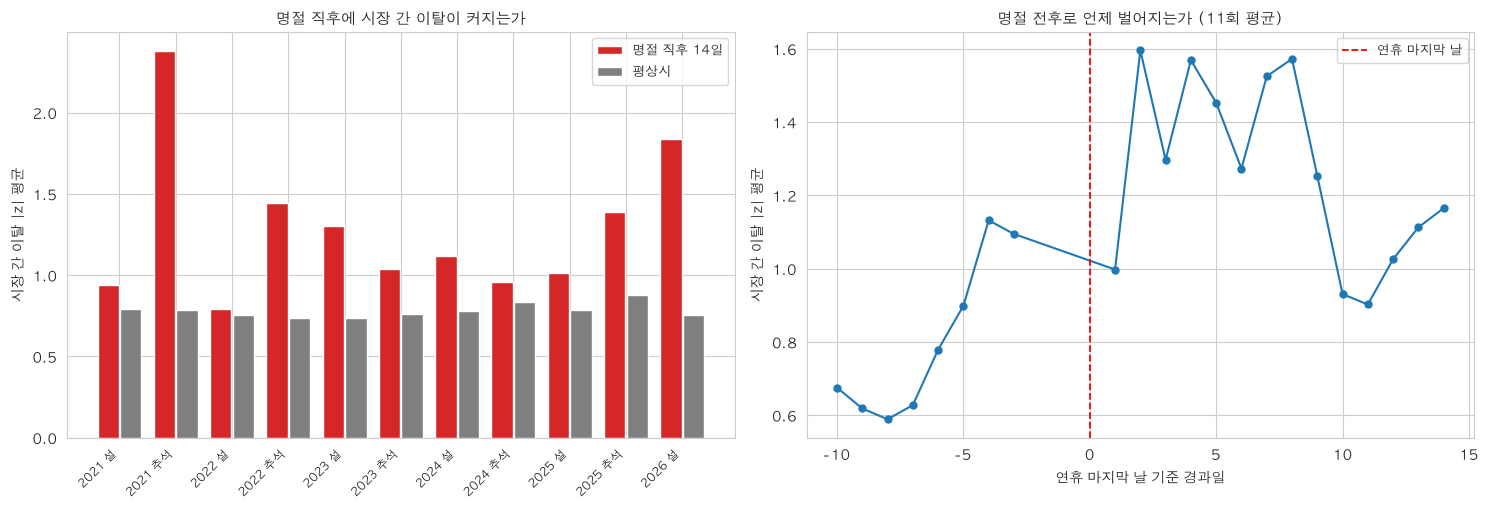

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

ax = axes[0]
x = np.arange(len(명절검정))
ax.bar(x - 0.2, 명절검정["직후 |z| 평균"], width=0.38, color="tab:red", label="명절 직후 14일")
ax.bar(x + 0.2, 명절검정["평상 |z| 평균"], width=0.38, color="tab:gray", label="평상시")
ax.set_xticks(x)
ax.set_xticklabels(명절검정.명절, rotation=45, ha="right", fontsize=8.5)
ax.set_ylabel("시장 간 이탈 |z| 평균")
ax.set_title("명절 직후에 시장 간 이탈이 커지는가", fontsize=11)
ax.legend(fontsize=9)

ax = axes[1]
prof = []
for 이름, 끝 in 연휴끝.items():
    for d in range(-10, 15):
        day = R[R.price_date == 끝 + pd.Timedelta(days=d)]
        if len(day):
            prof.append({"상대일": d, "|z|": day.z.abs().mean()})
prof = pd.DataFrame(prof).groupby("상대일")["|z|"].mean()
ax.plot(prof.index, prof.values, "o-", ms=5, color="tab:blue")
ax.axvline(0, color="red", ls="--", lw=1.3, label="연휴 마지막 날")
ax.set_xlabel("연휴 마지막 날 기준 경과일")
ax.set_ylabel("시장 간 이탈 |z| 평균")
ax.set_title("명절 전후로 언제 벌어지는가 (11회 평균)", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7. 정리

### 한 줄 요약

**일회성 처치 사건은 사실상 없습니다.** 5년 반 동안 2개뿐입니다. 대신
**명절 직후에 반복되는 구조**가 있습니다: 11번의 명절 **전부**에서 시장 간
이탈이 커졌습니다.

### 사건 탐색 결과

| 항목 | 결과 |
|---|---|
| 이탈일(z ≥ 3) | 시장별 13~31일 (0.95~2.26%) |
| **5거래일 이상 이어진 구간** | **단 2개** |
| 그중 시장 전체 사건(3품목 이상) | **2개 전부** |
| 관측 공백(휴장 후보) | **0건** — 5시장 모두 1,373일 전부 관측 |

| 사건 | 기간 | 일수 | 방향 | 평균 z | 걸린 품목 |
|---|---|---|---|---|---|
| 엄궁도매 | 2021-09-24 ~ 10-01 | 6 | 비쌈 | **7.47** | 11 / 15 |
| 오정도매 | 2026-02-20 ~ 02-26 | 5 | 쌈 | -3.45 | 8 / 17 |

**둘 다 명절 연휴가 끝난 이틀 뒤에 시작합니다.** 추석 연휴 종료 2021-09-22 →
사건 시작 09-24, 설 연휴 종료 2026-02-18 → 사건 시작 02-20.

### 우연이 아닙니다: 11번 중 11번

명절 날짜는 `kasi_special_day` 와 11개 전부 대조했습니다.

| 명절 | 직후 \|z\| | 평상시 \|z\| | 배수 | 가장 튄 시장 |
|---|---|---|---|---|
| 2021 추석 | 2.38 | 0.78 | **3.04** | 엄궁 (z 9.72) |
| 2026 설 | 1.84 | 0.76 | **2.43** | 엄궁 (4.58) |
| 2022 추석 | 1.44 | 0.74 | 1.95 | 엄궁 (5.11) |
| 2023 설 | 1.30 | 0.74 | 1.77 | 가락 (4.82) |
| 2025 추석 | 1.39 | 0.88 | 1.59 | 서부 (3.97) |
| … 나머지 6회 | | | 1.05~1.44 | |
| **전체** | **1.29** | **0.78** | **1.65** | |

**11회 전부 1을 넘습니다.** 예외가 하나도 없습니다. 명절 직후에는 시장 간
가격이 평소의 1.65배로 벌어집니다.

**엄궁도매(부산)가 11회 중 5회 최다 이탈**입니다. 가장 큰 두 사건도 엄궁입니다.

### 이게 뜻하는 것

**DiD 보다 이벤트 스터디가 맞습니다.**

| | DiD | 이벤트 스터디 |
|---|---|---|
| 필요한 것 | 처치군·대조군, 평행추세 | 사건 시점, 전후 궤적 |
| 이 데이터 | 일회성 사건 2개뿐 | **반복 사건 11회** |
| 22번의 걸림돌 | 평행추세 약함 | 사건별로 자기 기준선을 씀 |

22번에서 평행추세가 약해 DiD 가 어렵다고 봤는데, **사건이 반복되면 그 문제가
줄어듭니다**: 명절마다 직전 구간을 기준선으로 삼으면 됩니다.

### 한계 — 처치의 성격이 다릅니다

- **명절은 모든 시장에 걸립니다.** 한 시장만 처치받는 게 아니라 **정도가 다를
  뿐**입니다. "처치 vs 무처치"가 아니라 "처치 강도 차이"라, 통상적인 DiD
  프레임과는 다릅니다.
- **무작위 배정이 아닙니다.** 왜 엄궁이 자주 튀는지 모릅니다. 부산이라는 지리,
  산지와의 거리, 시장 규모 등이 섞여 있고 이 데이터로는 못 가릅니다.
- **명절 직후는 미거래도 늘어납니다.** 거래가 성사된 날만 남긴 값이라 선택
  편의가 명절 구간에서 더 클 수 있습니다. 2절 지수는 그 보정을 안 했습니다.
- **z 는 60거래일 중앙값 기준**이라 명절이 그 창에 들어가면 기준선 자체가
  오염됩니다. 사건 구간을 빼고 다시 재야 정확합니다.
- **이탈일이 0.95~2.26%** 로 정규분포 기대치(0.3%)보다 훨씬 많습니다. 꼬리가
  두껍다는 뜻이라, z 3 을 "드문 일"로 읽으면 안 됩니다.

### 다음

1. **이벤트 스터디 설계**: 명절 연휴 종료일을 0 으로 놓고 -10 ~ +14 거래일
   궤적을 시장별로 추정합니다. 6절 오른쪽 그림이 그 초안입니다.
2. **미거래 보정**: 명절 구간의 선택 편의를 어떻게 다룰지 정해야 합니다.
3. **엄궁이 왜 튀는지**는 이 데이터로 답할 수 없습니다. 답하려면 시장 규모·
   산지 거리 같은 외부 정보가 필요합니다.